In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import tensorflow as tf
import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
covid_path =r"D:\deeplearning\new x ray image classification using cnn\COVID-19_Radiography_Dataset\COVID\images"
normal_path =r"D:\deeplearning\new x ray image classification using cnn\COVID-19_Radiography_Dataset\Normal\images"

In [3]:
IMG_SIZE = (150,150)
BATCH_SIZE = 32

In [4]:
covid_images = glob.glob(covid_path + r"\*.png")
print("Number of COVID images:",len(covid_images))
normal_images = glob.glob(normal_path + r"\*.png")
print("Number of Normal images:",len(normal_images))

Number of COVID images: 3616
Number of Normal images: 10192


In [5]:
covid_df = pd.DataFrame({"filename":covid_images,"label":1})
normal_df = pd.DataFrame({"filename":normal_images,"label":0})
df = pd.concat([covid_df,normal_df],ignore_index=True)

In [6]:
print("\nDataset Shape:")
print(df.shape)
print("\nFirst 5 Records:")
print(df.head())
print("\nLast 5 Records:")
print(df.tail())
print("\nMissing Values:")
print(df.isnull().sum())
print("\n:Duplicated Records")
print(df.duplicated().sum())
df=df.drop_duplicates()


Dataset Shape:
(13808, 2)

First 5 Records:
                                            filename  label
0  D:\deeplearning\new x ray image classification...      1
1  D:\deeplearning\new x ray image classification...      1
2  D:\deeplearning\new x ray image classification...      1
3  D:\deeplearning\new x ray image classification...      1
4  D:\deeplearning\new x ray image classification...      1

Last 5 Records:
                                                filename  label
13803  D:\deeplearning\new x ray image classification...      0
13804  D:\deeplearning\new x ray image classification...      0
13805  D:\deeplearning\new x ray image classification...      0
13806  D:\deeplearning\new x ray image classification...      0
13807  D:\deeplearning\new x ray image classification...      0

Missing Values:
filename    0
label       0
dtype: int64

:Duplicated Records
0


In [7]:
df=pd.concat([covid_df,normal_df],ignore_index=True)

In [8]:
print("n class distribution:")
print(df["label"].value_counts())
print("\n class Names:")
print(df["label"].value_counts().rename(
    index={0:"Normal",1:"Covid"}))

n class distribution:
label
0    10192
1     3616
Name: count, dtype: int64

 class Names:
label
Normal    10192
Covid      3616
Name: count, dtype: int64


In [9]:
df = df.sample(frac=1,random_state=42).reset_index(drop=True)

train_df,test_df = train_test_split(df,test_size=0.20,random_state=42,stratify=df["label"])
print("\nTraining images:",len(train_df))
print("tesing image:",len(test_df))


Training images: 11046
tesing image: 2762


In [10]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.20)

# TEST DATA GENERATOR
test_datagen = ImageDataGenerator(
    rescale=1./255)

#TRAINING DATA GENERATOR
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="training",
    shuffle=True)

#VALIDATION DATA GENERATOR
validation_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="validation",
    shuffle=False)

# TEST DATA GENERATOR
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False)

# DISPLAY GENERATOR INFORMATION
print("\nTraining Samples:",train_generator.samples)
print("Validation Samples:",validation_generator.samples)
print("Testing Samples:",test_generator.samples)

Found 8837 validated image filenames.
Found 2209 validated image filenames.
Found 2762 validated image filenames.

Training Samples: 8837
Validation Samples: 2209
Testing Samples: 2762


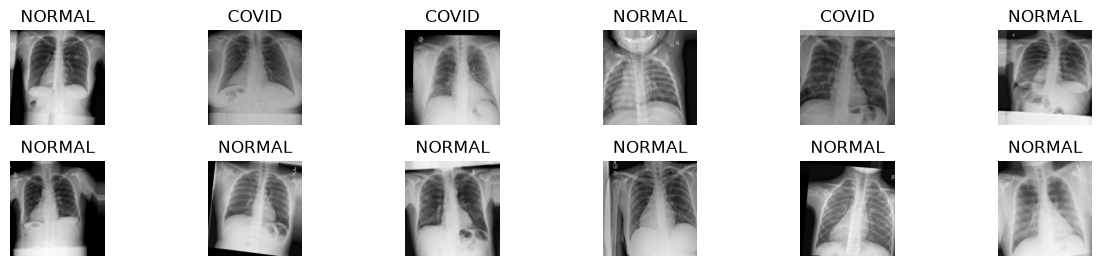

In [11]:
images,labels = next(train_generator)
plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(6,6,i+1)
    plt.imshow(images[i])
    if labels[i] == 1:
        plt.title("COVID")
    else:
        plt.title("NORMAL")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [12]:
model = Sequential([

    Conv2D(32, (3, 3), activation="relu",
           input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    # Output layer
    Dense(1, activation="sigmoid")
])
model = Sequential([

    Conv2D(32, (3, 3), activation="relu",
           input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    # Output layer
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

c:\Users\Admin-THC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
history = model.fit(train_generator,
                     validation_data = validation_generator,
                     epochs = 10)
test_loss, test_accuracy = model.evaluate(test_generator)
print("TEST RESULTS")
print("Test loss: " , test_loss)
print("Testaccuracy: ", test_accuracy)

Epoch 1/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 0.7377 - loss: 0.5369 - val_accuracy: 0.7370 - val_loss: 0.4818
Epoch 2/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 185s 668ms/step - accuracy: 0.7720 - loss: 0.4547 - val_accuracy: 0.7551 - val_loss: 0.4736
Epoch 3/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 201s 725ms/step - accuracy: 0.7999 - loss: 0.4164 - val_accuracy: 0.7664 - val_loss: 0.4384
Epoch 4/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 307s 1s/step - accuracy: 0.8297 - loss: 0.3694 - val_accuracy: 0.8533 - val_loss: 0.3261
Epoch 5/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 200s 724ms/step - accuracy: 0.8495 - loss: 0.3368 - val_accuracy: 0.8723 - val_loss: 0.3055
Epoch 6/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 226s 816ms/step - accuracy: 0.8677 - loss: 0.3069 - val_accuracy: 0.8732 - val_loss: 0.2800
Epoch 7/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - accuracy: 0.8808 - loss: 0.2853 - val_accuracy: 0.8923 - val_loss: 0.2446
Epoch 8/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 348s 1s/step - accuracy: 0.8854 - loss: 0.271

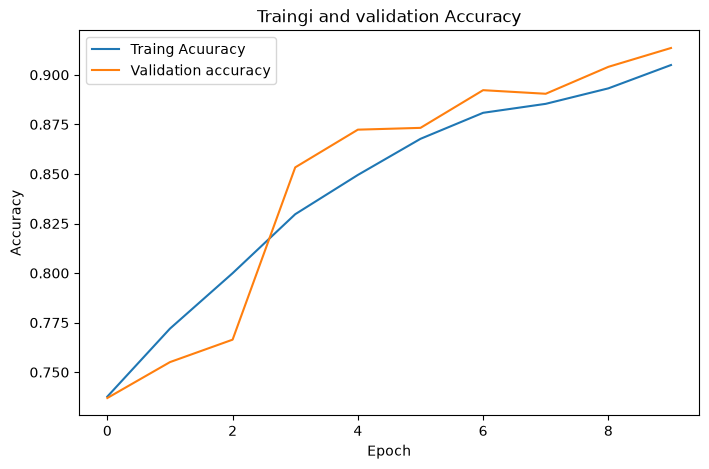

In [15]:
plt.figure(figsize =(8,5))
plt.plot(history.history["accuracy"],
label  = "Traing Acuuracy")

plt.plot(history.history["val_accuracy"],
label = "Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Traingi and validation Accuracy")
plt.legend()
plt.show()


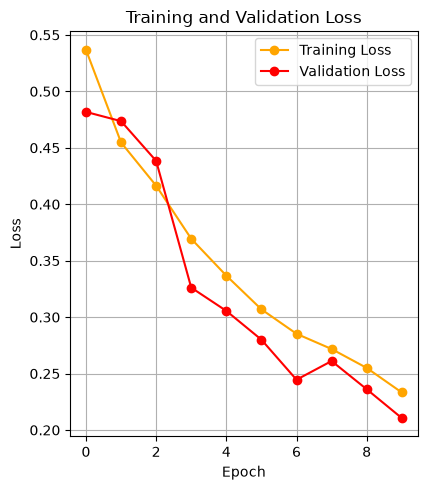

In [16]:
plt.figure(figsize = (8, 5))

#Loss Plot

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss", color='orange', marker='o')
plt.plot(history.history["val_loss"], label="Validation Loss", color='red', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()